In [3]:
from google.colab import drive

drive.mount('/content/drive')
path = '/content/drive/MyDrive/Datasheet/credit_card_fraud_10k.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd

df = pd.read_csv(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [5]:
df.drop(columns='transaction_id', inplace=True)

In [6]:
df.isnull().sum()

,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [7]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,9849
1,151


In [8]:
df['is_fraud'].value_counts(normalize=True)*100

,proportion
is_fraud,
0,98.49
1,1.51


In [9]:
df.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

**Feature Engineering**

In [10]:
import numpy as np

df['hour_sin'] = np.sin (2 * np.pi * df['transaction_hour']/24)
df['hour_cos'] = np.cos (2 * np.pi * df['transaction_hour']/24)

In [11]:
df.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud', 'hour_sin',
       'hour_cos'],
      dtype='object')

**Preprocessing**

In [14]:
Feature = ['amount','hour_sin','hour_cos','foreign_transaction','location_mismatch','device_trust_score','velocity_last_24h','cardholder_age']
X = df[Feature]
y = df['is_fraud']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.2, stratify=y)
print(f'Jumlah data training adalah : {len(X_train)} dan jumlah data uji adalah : {len(X_test)}')

Jumlah data training adalah : 8000 dan jumlah data uji adalah : 2000


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_feature = ['amount','device_trust_score','velocity_last_24h','cardholder_age']
num_transform = scaler

In [17]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_transform, num_feature)
], remainder = 'passthrough')

In [18]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [19]:
from catboost import CatBoostClassifier

baseline_catboost = CatBoostClassifier(
    random_state = 42
)

**Model Baseline**

In [20]:
from sklearn.pipeline import Pipeline

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', baseline_catboost)
])

In [21]:
baseline_pipeline.fit(X_train, y_train)

Learning rate set to 0.025035
0:	learn: 0.6254348	total: 68.8ms	remaining: 1m 8s
1:	learn: 0.5701006	total: 83.2ms	remaining: 41.5s
2:	learn: 0.5044171	total: 97.2ms	remaining: 32.3s
3:	learn: 0.4569994	total: 111ms	remaining: 27.6s
4:	learn: 0.4251003	total: 118ms	remaining: 23.4s
5:	learn: 0.3845414	total: 129ms	remaining: 21.4s
6:	learn: 0.3385026	total: 141ms	remaining: 20s
7:	learn: 0.3125719	total: 152ms	remaining: 18.9s
8:	learn: 0.2875833	total: 164ms	remaining: 18.1s
9:	learn: 0.2638732	total: 176ms	remaining: 17.4s
10:	learn: 0.2403665	total: 188ms	remaining: 16.9s
11:	learn: 0.2237385	total: 203ms	remaining: 16.7s
12:	learn: 0.2057889	total: 211ms	remaining: 16s
13:	learn: 0.1885582	total: 223ms	remaining: 15.7s
14:	learn: 0.1744964	total: 236ms	remaining: 15.5s
15:	learn: 0.1587862	total: 242ms	remaining: 14.9s
16:	learn: 0.1504207	total: 249ms	remaining: 14.4s
17:	learn: 0.1375118	total: 255ms	remaining: 13.9s
18:	learn: 0.1239315	total: 259ms	remaining: 13.3s
19:	learn: 0

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('model', CatBoostClassifier(random_state=42))])

In [22]:
y_pred_baseline = baseline_pipeline.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, roc_auc_score, confusion_matrix

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline)
recall_baseline = recall_score(y_test, y_pred_baseline)
print(f'Akurasi model baseline adalah : {accuracy_baseline:.4f}')
print(f'Precision model baseline adalah : {precision_baseline:.4f}')
print(f'Recall model baseline adalah : {recall_baseline:.4f}')
print(classification_report(y_test, y_pred_baseline))

Akurasi model baseline adalah : 1.0000
Precision model baseline adalah : 1.0000
Recall model baseline adalah : 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [25]:
y_prob_baseline = baseline_pipeline.predict_proba(X_test)[:,1]

In [26]:
roc_auc_baseline = roc_auc_score(y_test, y_prob_baseline)
print(f'ROC AUC score baseline : {roc_auc_baseline:.4f}')

ROC AUC score baseline : 1.0000


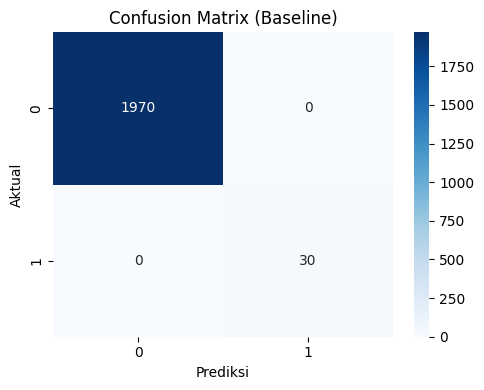

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(5,4))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Baseline)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

**Model SMOTE**

In [32]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbPipeline

smote_pipeline = imbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', baseline_catboost)
])

In [33]:
smote_pipeline.fit(X_train, y_train)

Learning rate set to 0.03344
0:	learn: 0.5959266	total: 14.3ms	remaining: 14.3s
1:	learn: 0.5126072	total: 25.6ms	remaining: 12.8s
2:	learn: 0.4432911	total: 36.8ms	remaining: 12.2s
3:	learn: 0.3822795	total: 48.5ms	remaining: 12.1s
4:	learn: 0.3304570	total: 59.8ms	remaining: 11.9s
5:	learn: 0.2884393	total: 73.3ms	remaining: 12.1s
6:	learn: 0.2492849	total: 84.2ms	remaining: 11.9s
7:	learn: 0.2173180	total: 95.4ms	remaining: 11.8s
8:	learn: 0.1909661	total: 107ms	remaining: 11.7s
9:	learn: 0.1660290	total: 121ms	remaining: 12s
10:	learn: 0.1465402	total: 132ms	remaining: 11.9s
11:	learn: 0.1309998	total: 143ms	remaining: 11.8s
12:	learn: 0.1176615	total: 154ms	remaining: 11.7s
13:	learn: 0.1035850	total: 167ms	remaining: 11.7s
14:	learn: 0.0935956	total: 178ms	remaining: 11.7s
15:	learn: 0.0835749	total: 189ms	remaining: 11.6s
16:	learn: 0.0765073	total: 202ms	remaining: 11.7s
17:	learn: 0.0698555	total: 212ms	remaining: 11.6s
18:	learn: 0.0651840	total: 223ms	remaining: 11.5s
19:	le

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', CatBoostClassifier(random_state=42))])

In [34]:
y_pred_smote = smote_pipeline.predict(X_test)

In [35]:
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
print(f'Akurasi model smote adalah : {accuracy_smote:.4f}')
print(f'Precision model smote adalah : {precision_smote:.4f}')
print(f'Recall model smote adalah : {recall_smote:.4f}')
print(classification_report(y_test, y_pred_smote))

Akurasi model smote adalah : 0.9990
Precision model smote adalah : 0.9375
Recall model smote adalah : 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       0.94      1.00      0.97        30

    accuracy                           1.00      2000
   macro avg       0.97      1.00      0.98      2000
weighted avg       1.00      1.00      1.00      2000



In [36]:
y_prob_smote = smote_pipeline.predict_proba(X_test)[:,1]

In [37]:
roc_auc_smote = roc_auc_score(y_test, y_pred_smote)
print(f'ROC AUC smote adalah : {roc_auc_smote:.4f}')

ROC AUC smote adalah : 0.9995


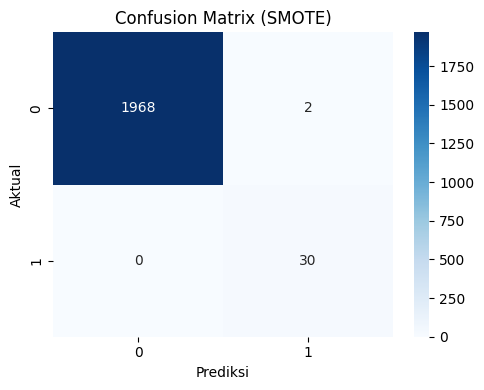

In [38]:
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(5,4))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (SMOTE)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

**Model Hyperparameter Tuning dengan Baseline**

In [39]:
params_grid = {
    'model__iterations' : [100, 150, 200],
    'model__depth' : [4, 6, 8],
    'model__learning_rate' : [0.01, 0.05, 0.1],
    'model__l2_leaf_reg' : [3, 5, 7],
    'model__subsample' : [0.8, 1.0]
}

In [40]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator = baseline_pipeline,
    param_grid = params_grid,
    scoring = 'f1',
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

In [41]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
0:	learn: 0.4559295	total: 5.74ms	remaining: 1.14s
1:	learn: 0.2830529	total: 9.46ms	remaining: 937ms
2:	learn: 0.1814535	total: 13.1ms	remaining: 861ms
3:	learn: 0.1249357	total: 16.7ms	remaining: 816ms
4:	learn: 0.0891807	total: 20.2ms	remaining: 789ms
5:	learn: 0.0653934	total: 23.8ms	remaining: 769ms
6:	learn: 0.0498577	total: 27.4ms	remaining: 755ms
7:	learn: 0.0389641	total: 30.9ms	remaining: 741ms
8:	learn: 0.0303474	total: 34.4ms	remaining: 729ms
9:	learn: 0.0243297	total: 37.8ms	remaining: 719ms
10:	learn: 0.0194916	total: 41.3ms	remaining: 710ms
11:	learn: 0.0159028	total: 44.9ms	remaining: 703ms
12:	learn: 0.0138137	total: 48.3ms	remaining: 695ms
13:	learn: 0.0121027	total: 51.9ms	remaining: 689ms
14:	learn: 0.0103068	total: 55.3ms	remaining: 682ms
15:	learn: 0.0088314	total: 58.8ms	remaining: 677ms
16:	learn: 0.0080629	total: 62.3ms	remaining: 671ms
17:	learn: 0.0071720	total: 65.7ms	remaining: 665ms
18:	learn: 

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['amount',
                                                                          'device_trust_score',
                                                                          'velocity_last_24h',
                                                                          'cardholder_age'])])),
                                       ('model',
                                        CatBoostClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__depth': [4, 6, 8],
                         'model__iterations': [100, 150, 200],
                         'model__l2_leaf_reg': [3, 5, 7],
                         'model__learning_rate': [0.01, 0.05, 0.1],
                         'model__subsample': [0.8, 1.0]},
             scoring='f1', verbose=1)

In [42]:
print(grid_search.best_params_)

{'model__depth': 8, 'model__iterations': 200, 'model__l2_leaf_reg': 3, 'model__learning_rate': 0.1, 'model__subsample': 1.0}


In [43]:
best_catboost = grid_search.best_estimator_

In [44]:
y_pred = best_catboost.predict(X_test)

In [46]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f'Akurasi model adalah : {accuracy:.4f}')
print(f'Precision model adalah : {precision:.4f}')
print(f'Recall model adalah : {recall:.4f}')
print(classification_report(y_test, y_pred))

Akurasi model adalah : 1.0000
Precision model adalah : 1.0000
Recall model adalah : 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [47]:
y_prob = best_catboost.predict_proba(X_test)[:,1]

In [48]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f'ROC AUC score adalah : {roc_auc:.4f}')

ROC AUC score adalah : 1.0000


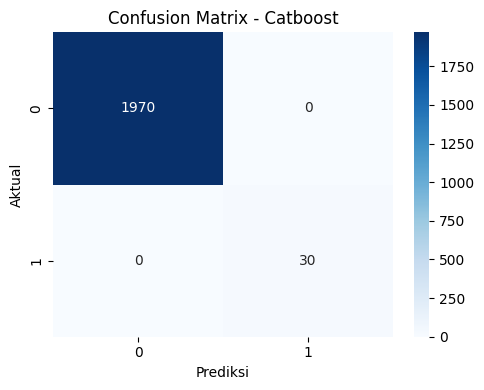

In [50]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Catboost')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [51]:
features_names = X.columns

importance = pd.DataFrame({
    'Feature' : features_names,
    'Importance' : best_catboost.named_steps['model'].feature_importances_
})

In [52]:
importance = importance.sort_values(
    by = 'Importance',
    ascending = False
)

In [53]:
print(importance)

               Feature  Importance
1             hour_sin   23.262345
5   device_trust_score   16.705088
6    velocity_last_24h   16.443424
2             hour_cos   15.322533
7       cardholder_age   15.156061
4    location_mismatch    7.010501
0               amount    4.277485
3  foreign_transaction    1.822563


/tmp/ipykernel_1477/1032781918.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


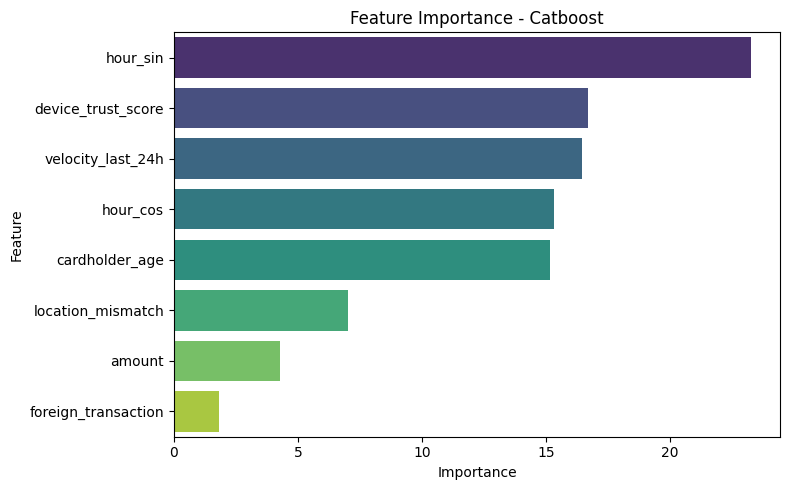

In [54]:
plt.figure(figsize=(8,5))
sns.barplot(
    data= importance,
    x = 'Importance',
    y = 'Feature',
    palette = 'viridis'
)
plt.title('Feature Importance - Catboost')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [55]:
from google.colab import files
import joblib

joblib.dump(best_catboost, 'Catboost_model.joblib')
files.download('Catboost_model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>